# **HEALTHCARE ANALYTICS AND PREDICTIVE INSIGHTS** 

#### **PHASE 1: WEB SCRAPING**

In [1]:
import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:


def extract_capstone_healthcare_dataset(records=1111):

    base_url = "https://health.data.ny.gov/resource/yjgt-tq93.json"

    columns = [
        "age_group",
        "gender",
        "race",
        "facility_name",
        "hospital_county",
        "ccsr_diagnosis_description",
        "length_of_stay",
        "type_of_admission",
        "total_charges",
        "total_costs",
        "payment_typology_1",
        "patient_disposition",
        "discharge_year"
    ]

    params = {
        "$select": ",".join(columns),
        "$limit": records
    }

    response = requests.get(base_url, params=params, timeout=30)

    if response.status_code != 200:
        print("Error:", response.status_code)
        return None

    df = pd.DataFrame(response.json())

    rename_map = {
        "age_group": "Age_Group",
        "gender": "Gender",
        "race": "Race",
        "facility_name": "Hospital_Name",
        "hospital_county": "County",
        "ccsr_diagnosis_description": "Diagnosis_Category",
        "length_of_stay": "Length_of_Stay",
        "type_of_admission": "Admission_Type",
        "total_charges": "Total_Charges",
        "total_costs": "Total_Costs",
        "payment_typology_1": "Insurance_Type",
        "patient_disposition": "Discharge_Status",
        "discharge_year": "Year"
    }

    df.rename(columns=rename_map, inplace=True)

    # Remove rows with missing target values
    df = df.dropna(
        subset=[
            "Total_Charges",
            "Total_Costs",
            "Length_of_Stay"
        ]
    )

    df.to_csv(
        "healthcare_capstone_dataset.csv",
        index=False
    )

    print("Shape:", df.shape)

    return df


df = extract_capstone_healthcare_dataset(1111)

Shape: (1111, 13)


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1111 entries, 0 to 1110
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age_Group           1111 non-null   str  
 1   Gender              1111 non-null   str  
 2   Race                1111 non-null   str  
 3   Hospital_Name       1111 non-null   str  
 4   County              1107 non-null   str  
 5   Diagnosis_Category  1111 non-null   str  
 6   Length_of_Stay      1111 non-null   str  
 7   Admission_Type      1111 non-null   str  
 8   Total_Charges       1111 non-null   str  
 9   Total_Costs         1111 non-null   str  
 10  Insurance_Type      1111 non-null   str  
 11  Discharge_Status    1111 non-null   str  
 12  Year                1111 non-null   str  
dtypes: str(13)
memory usage: 113.0 KB


In [11]:
df.head()

,Age_Group,Gender,Race,Hospital_Name,County,Diagnosis_Category,Length_of_Stay,Admission_Type,Total_Charges,Total_Costs,Insurance_Type,Discharge_Status,Year
0,50 to 69,F,White,Columbia Memorial Hospital,Columbia,CEREBRAL INFARCTION,2,Elective,17591.41,3570.06,"Managed Care, Unspecified",Short-term Hospital,2018
1,50 to 69,F,Black/African American,Harlem Hospital Center,Manhattan,POSTPROCEDURAL OR POSTOPERATIVE RESPIRATORY SY...,16,Emergency,106190.21,78913.24,Medicare,Short-term Hospital,2018
2,50 to 69,F,Black/African American,Harlem Hospital Center,Manhattan,BIPOLAR AND RELATED DISORDERS,4,Emergency,5600.00,4161.53,Medicaid,Home or Self Care,2018
3,18 to 29,M,Black/African American,Kings County Hospital Center,Kings,CARDIAC DYSRHYTHMIAS,2,Emergency,15965.54,11341.30,Medicaid,Home or Self Care,2018
4,0 to 17,M,Multi-racial,New York-Presbyterian Hospital - Columbia Pres...,Manhattan,PNEUMONIA (EXCEPT THAT CAUSED BY TUBERCULOSIS),2,Emergency,36846.83,10240.02,Medicaid,Home or Self Care,2018


In [12]:
df.to_csv("healthcare_capstone_dataset.csv", index=False)
print("Dataset saved successfully")

Dataset saved successfully


#### **PHASE 2: DATA CLEANING & PREPROCESSING**

In [13]:
# Checked missing values

print(df.isnull().sum())

Age_Group             0
Gender                0
Race                  0
Hospital_Name         0
County                4
Diagnosis_Category    0
Length_of_Stay        0
Admission_Type        0
Total_Charges         0
Total_Costs           0
Insurance_Type        0
Discharge_Status      0
Year                  0
dtype: int64


In [14]:
# Fill Missing County Values
df['County'] = df['County'].fillna('Unknown')

In [15]:
# Checked for Duplicate Records
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


In [16]:
# Checked Unique Values in Categorical Column
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].unique())


Age_Group
<StringArray>
['50 to 69', '18 to 29', '0 to 17', '30 to 49', '70 or Older']
Length: 5, dtype: str

Gender
<StringArray>
['F', 'M']
Length: 2, dtype: str

Race
<StringArray>
['White', 'Black/African American', 'Multi-racial', 'Other Race']
Length: 4, dtype: str

Hospital_Name
<StringArray>
[                                          'Columbia Memorial Hospital',
                                               'Harlem Hospital Center',
                                         'Kings County Hospital Center',
        'New York-Presbyterian Hospital - Columbia Presbyterian Center',
                                            'Maimonides Medical Center',
                                         'White Plains Hospital Center',
                                            'SJRH - Park Care Pavilion',
                                    'Long Island Jewish Medical Center',
                   'Montefiore Medical Center - Henry & Lucy Moses Div',
                                       'B

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19912\3761601523.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [17]:
# Remove Leading/Trailing Spaces
for col in cat_cols:
    df[col] = df[col].str.strip()

In [18]:
# Standardize Capitalization

for col in cat_cols:
    df[col] = df[col].str.title()

In [19]:
# Checked the datatypes
print(df.dtypes)

Age_Group             str
Gender                str
Race                  str
Hospital_Name         str
County                str
Diagnosis_Category    str
Length_of_Stay        str
Admission_Type        str
Total_Charges         str
Total_Costs           str
Insurance_Type        str
Discharge_Status      str
Year                  str
dtype: object


In [20]:
# Converted Total_Charges and Total_Costs to float
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')
df['Total_Costs'] = pd.to_numeric(df['Total_Costs'], errors='coerce')

# Converted Year to integer
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')

In [21]:
# checked the datatypes of converted columns
print(df[['Total_Charges', 'Total_Costs', 'Year']].dtypes)

Total_Charges    float64
Total_Costs      float64
Year               Int64
dtype: object


In [22]:
# checked the missing values after conversion
print(df[['Total_Charges', 'Total_Costs', 'Year']].isnull().sum())

Total_Charges    0
Total_Costs      0
Year             0
dtype: int64


In [23]:
# Display duplicate rows
duplicates = df[df.duplicated()]
print(duplicates)

    Age_Group Gender        Race  \
212   0 To 17      F  Other Race   

                                         Hospital_Name County  \
212  Montefiore Med Center - Jack D Weiler Hosp Of ...  Bronx   

    Diagnosis_Category Length_of_Stay Admission_Type  Total_Charges  \
212           Liveborn              2        Newborn       13053.91   

     Total_Costs Insurance_Type   Discharge_Status  Year  
212      1843.87       Medicaid  Home Or Self Care  2018  


In [24]:
# Remove all exact duplicate rows
df.drop_duplicates(inplace=True)

In [25]:
print("Duplicate rows remaining:", df.duplicated().sum())
print("New shape:", df.shape)

Duplicate rows remaining: 0
New shape: (1110, 13)


#### Feature Engineering

In [26]:
# created a column for aggregations
df['Profit_Margin'] = df['Total_Charges'] - df['Total_Costs']
print(df['Profit_Margin'])


0        14021.35
1        27276.97
2         1438.47
3         4624.24
4        26606.81
          ...    
1106     33849.46
1107     18303.50
1108    241725.76
1109      6220.80
1110     12268.53
Name: Profit_Margin, Length: 1110, dtype: float64


In [27]:
df['Charge_Cost_Ratio'] = df['Total_Charges'] / df['Total_Costs']
print(df['Charge_Cost_Ratio'])

0       4.927483
1       1.345658
2       1.345659
3       1.407735
4       3.598316
          ...   
1106    4.183135
1107    3.743692
1108    4.078234
1109    3.667238
1110    4.062982
Name: Charge_Cost_Ratio, Length: 1110, dtype: float64


In [28]:
df.head()

,Age_Group,Gender,Race,Hospital_Name,County,Diagnosis_Category,Length_of_Stay,Admission_Type,Total_Charges,Total_Costs,Insurance_Type,Discharge_Status,Year,Profit_Margin,Charge_Cost_Ratio
0,50 To 69,F,White,Columbia Memorial Hospital,Columbia,Cerebral Infarction,2,Elective,17591.41,3570.06,"Managed Care, Unspecified",Short-Term Hospital,2018,14021.35,4.927483
1,50 To 69,F,Black/African American,Harlem Hospital Center,Manhattan,Postprocedural Or Postoperative Respiratory Sy...,16,Emergency,106190.21,78913.24,Medicare,Short-Term Hospital,2018,27276.97,1.345658
2,50 To 69,F,Black/African American,Harlem Hospital Center,Manhattan,Bipolar And Related Disorders,4,Emergency,5600.00,4161.53,Medicaid,Home Or Self Care,2018,1438.47,1.345659
3,18 To 29,M,Black/African American,Kings County Hospital Center,Kings,Cardiac Dysrhythmias,2,Emergency,15965.54,11341.30,Medicaid,Home Or Self Care,2018,4624.24,1.407735
4,0 To 17,M,Multi-Racial,New York-Presbyterian Hospital - Columbia Pres...,Manhattan,Pneumonia (Except That Caused By Tuberculosis),2,Emergency,36846.83,10240.02,Medicaid,Home Or Self Care,2018,26606.81,3.598316


In [29]:
# Generate a Data Quality Report
quality_report = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})

print(quality_report)

                   Data Type  Missing Values  Unique Values
Age_Group                str               0              5
Gender                   str               0              2
Race                     str               0              4
Hospital_Name            str               0             70
County                   str               0             25
Diagnosis_Category       str               0            203
Length_of_Stay           str               0             41
Admission_Type           str               0              6
Total_Charges        float64               0           1106
Total_Costs          float64               0           1106
Insurance_Type           str               0              8
Discharge_Status         str               0             16
Year                   Int64               0              1
Profit_Margin        float64               0           1106
Charge_Cost_Ratio    float64               0           1106


In [30]:
# Saved cleaned dataset
df.to_csv("healthcare_dataset_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


#### **PHASE 3 : EXPLORATORY DATA ANALYSIS (EDA)**

In [31]:
# Load cleaned dataset
df = pd.read_csv("healthcare_dataset_cleaned.csv")
df.head()

,Age_Group,Gender,Race,Hospital_Name,County,Diagnosis_Category,Length_of_Stay,Admission_Type,Total_Charges,Total_Costs,Insurance_Type,Discharge_Status,Year,Profit_Margin,Charge_Cost_Ratio
0,50 To 69,F,White,Columbia Memorial Hospital,Columbia,Cerebral Infarction,2,Elective,17591.41,3570.06,"Managed Care, Unspecified",Short-Term Hospital,2018,14021.35,4.927483
1,50 To 69,F,Black/African American,Harlem Hospital Center,Manhattan,Postprocedural Or Postoperative Respiratory Sy...,16,Emergency,106190.21,78913.24,Medicare,Short-Term Hospital,2018,27276.97,1.345658
2,50 To 69,F,Black/African American,Harlem Hospital Center,Manhattan,Bipolar And Related Disorders,4,Emergency,5600.00,4161.53,Medicaid,Home Or Self Care,2018,1438.47,1.345659
3,18 To 29,M,Black/African American,Kings County Hospital Center,Kings,Cardiac Dysrhythmias,2,Emergency,15965.54,11341.30,Medicaid,Home Or Self Care,2018,4624.24,1.407735
4,0 To 17,M,Multi-Racial,New York-Presbyterian Hospital - Columbia Pres...,Manhattan,Pneumonia (Except That Caused By Tuberculosis),2,Emergency,36846.83,10240.02,Medicaid,Home Or Self Care,2018,26606.81,3.598316


#### Dataset Overview

In [32]:
# Shape
print("Rows and Columns:", df.shape)

Rows and Columns: (1110, 15)


In [33]:
# Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1110 entries, 0 to 1109
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age_Group           1110 non-null   str    
 1   Gender              1110 non-null   str    
 2   Race                1110 non-null   str    
 3   Hospital_Name       1110 non-null   str    
 4   County              1110 non-null   str    
 5   Diagnosis_Category  1110 non-null   str    
 6   Length_of_Stay      1110 non-null   str    
 7   Admission_Type      1110 non-null   str    
 8   Total_Charges       1110 non-null   float64
 9   Total_Costs         1110 non-null   float64
 10  Insurance_Type      1110 non-null   str    
 11  Discharge_Status    1110 non-null   str    
 12  Year                1110 non-null   int64  
 13  Profit_Margin       1110 non-null   float64
 14  Charge_Cost_Ratio   1110 non-null   float64
dtypes: float64(4), int64(1), str(10)
memory usage: 130.2 KB


In [34]:
# Statistical Summary
df.describe()

,Total_Charges,Total_Costs,Year,Profit_Margin,Charge_Cost_Ratio
count,1.110000e+03,1110.000000,1110.0,1.110000e+03,1110.000000
mean,5.673234e+04,17177.764297,2018.0,3.955458e+04,3.712094
std,1.334416e+05,35918.454633,0.0,1.008919e+05,2.165803
min,2.263990e+03,404.230000,2018.0,-3.317376e+04,0.668747
25%,1.489308e+04,4785.920000,2018.0,8.789028e+03,2.509618
50%,2.964622e+04,9277.520000,2018.0,2.011436e+04,3.511810
75%,6.214042e+04,17986.747500,2018.0,4.357831e+04,4.454304
max,3.489608e+06,741356.840000,2018.0,2.748251e+06,23.522201


In [35]:
# Categorical Summary
df.describe(include='object')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19912\306805595.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Age_Group,Gender,Race,Hospital_Name,County,Diagnosis_Category,Length_of_Stay,Admission_Type,Insurance_Type,Discharge_Status
count,1110,1110,1110,1110,1110,1110,1110,1110,1110,1110
unique,5,2,4,70,25,203,41,6,8,16
top,50 To 69,F,White,New York-Presbyterian Hospital - New York Weil...,Queens,Liveborn,2,Emergency,Medicare,Home Or Self Care
freq,301,620,511,93,220,86,246,763,391,727


##### The dataset contains patient demographics, hospital information, diagnosis details, admission types, costs, insurance details, and discharge outcomes.

##### Analyze Patient Demographics

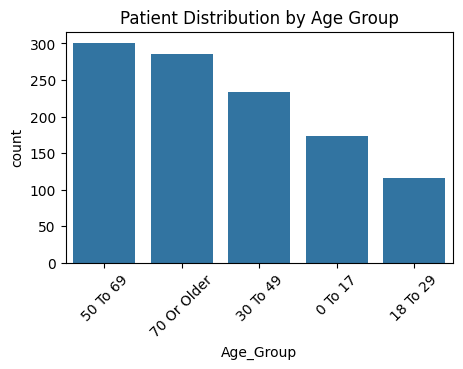

In [36]:
# Age Group Distribution
plt.figure(figsize=(5,3))

sns.countplot(
    x='Age_Group',
    data=df,
    order=df['Age_Group'].value_counts().index
)

plt.xticks(rotation=45)
plt.title('Patient Distribution by Age Group')
plt.show()

    -Which age group has the highest admissions? - 50-69 age group
    -Which age group has the lowest admissions? - 18-29 age group

The 50–69 age group accounts for the highest number of hospital admissions, indicating that middle-aged and elderly individuals utilize healthcare services more frequently than younger populations. The lowest admissions were observed among younger age groups, suggesting relatively lower hospitalization rates.

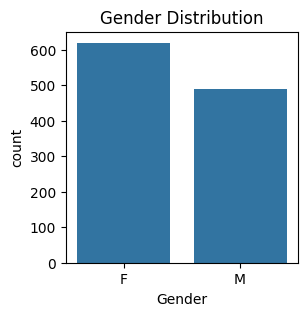

In [37]:
# Gender Distribution
# Compare male vs female admissions.
plt.figure(figsize=(3,3))

sns.countplot(
    x='Gender',
    data=df
)

plt.title('Gender Distribution')
plt.show()

The distribution of admissions across genders appears relatively balanced, indicating that healthcare utilization is not heavily concentrated within a single gender group. Any observed difference may reflect demographic patterns in the underlying population.

##### Hospital Analysis

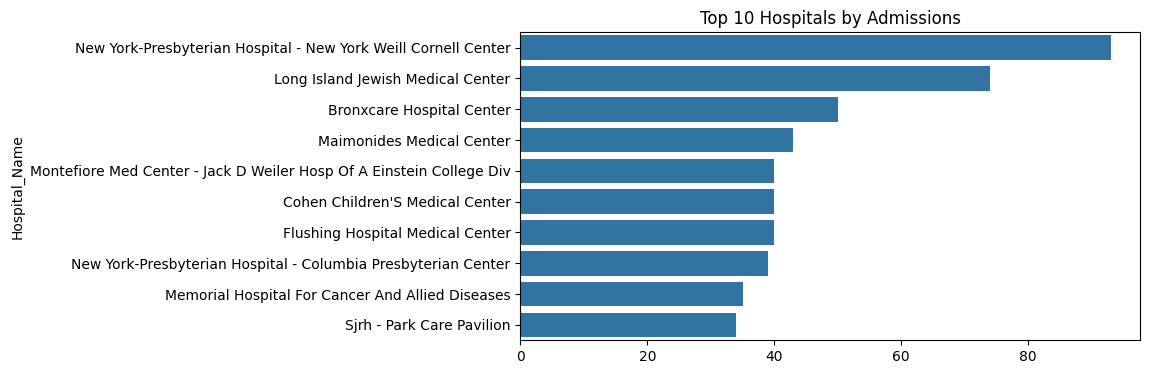

In [38]:
# Identify hospitals with highest patient volume.
top_hospitals = df['Hospital_Name'].value_counts().head(10)

plt.figure(figsize=(8,4))

sns.barplot(
    x=top_hospitals.values,
    y=top_hospitals.index
)

plt.title('Top 10 Hospitals by Admissions')
plt.show()

A small number of hospitals account for a significant proportion of total admissions, suggesting that these facilities serve as major healthcare providers within the region. High patient volumes may indicate greater capacity, specialized services, or wider geographic coverage.

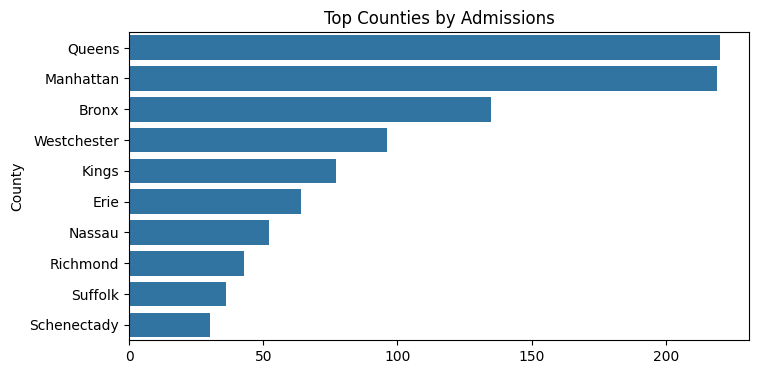

In [39]:
# County Analysis
top_counties = df['County'].value_counts().head(10)

plt.figure(figsize=(8,4))

sns.barplot(
    x=top_counties.values,
    y=top_counties.index
)

plt.title('Top Counties by Admissions')
plt.show()

Which county contributes the most admissions? - Queens

Queens recorded the highest number of patient admissions, indicating a greater demand for healthcare services in this county. This may be influenced by population size, healthcare infrastructure, or regional healthcare needs.

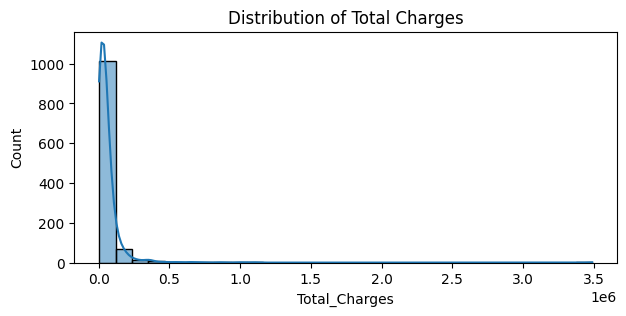

In [40]:
# Charges Distribution
plt.figure(figsize=(7,3))

sns.histplot(
    df['Total_Charges'],
    bins=30,
    kde=True
)

plt.title('Distribution of Total Charges')
plt.show()

The distribution of total charges is positively skewed, with most patients incurring moderate charges while a small number of cases generate exceptionally high billing amounts. This indicates variability in treatment complexity and resource utilization.

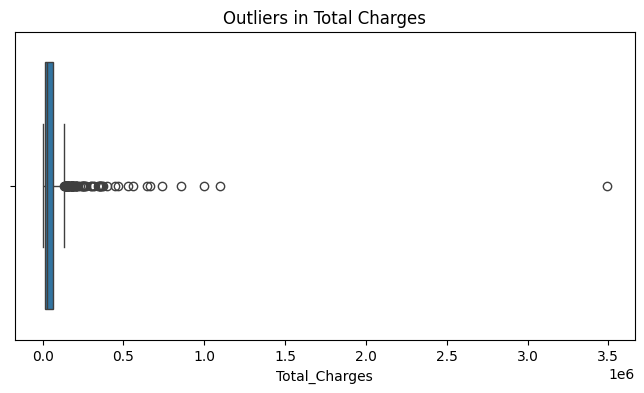

In [41]:
# Outlier Detection
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['Total_Charges']
)

plt.title('Outliers in Total Charges')
plt.show()

Several outliers were identified in total charges, indicating the presence of unusually expensive healthcare cases. These outliers may correspond to specialized treatments, critical care, or prolonged hospitalization periods.

In [42]:
# Correlation Heatmap
numerical_cols = [
    'Total_Charges',
    'Total_Costs',
    'Profit_Margin',
    'Year'
]

corr = df[numerical_cols].corr()

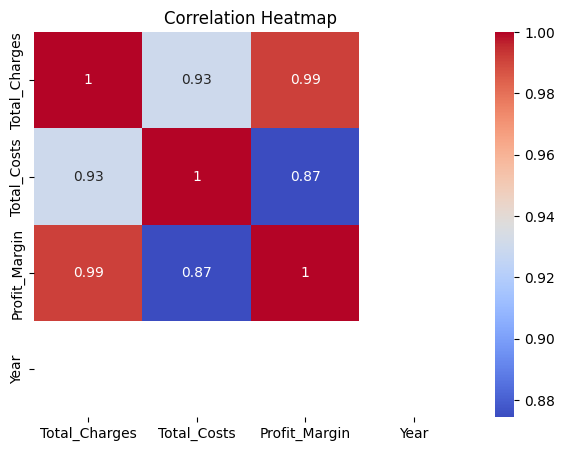

In [44]:
# Heatmap Visualization
plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

Total Charges and Total Costs exhibit a strong positive correlation (approximately 0.93), indicating that these variables move closely together. Profit Margin also shows meaningful relationships with financial metrics, while Year demonstrates comparatively weaker associations.

#### **Key Findings**
- Most admitted age group: **50-69**
- Highest admission county: **Queens**
- Charges and costs show **Strong Positive correlation.**
- Outliers exist/do not exist in healthcare expenses - **Yes, it exists.**

#### **PHASE 4: MACHINE LEARNING MODEL**

In [91]:
# Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [93]:
# Load Dataset
df = pd.read_csv("healthcare_dataset_cleaned.csv")

In [94]:
# Encode Categorical Variables
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16164\2793444071.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [95]:
# Define Features & Target
X = df.drop("Discharge_Status", axis=1)

y = df["Discharge_Status"]

In [96]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [97]:
# Train Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [98]:
# Predictions
y_pred = model.predict(X_test)

In [99]:
# Evaluate Model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6216216216216216


In [100]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         1
           6       0.66      0.94      0.78       136
           7       0.42      0.14      0.20        37
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         4
          11       0.00      0.00      0.00        11
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         4
          15       0.33      0.26      0.29        19

    accuracy                           0.62       222
   macro avg       0.13      0.12      0.12       222
weighted avg       0.50      0.62      0.53       222



c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [101]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[  0   0   0   4   0   0   0   0   0   0   0]
 [  0   0   0   4   0   0   0   0   0   0   0]
 [  0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0 128   4   0   0   0   0   0   4]
 [  0   0   0  28   5   0   0   0   0   0   4]
 [  0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0   3   0   0   0   0   0   0   1]
 [  0   0   0  11   0   0   0   0   0   0   0]
 [  0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0   3   0   0   0   0   0   0   1]
 [  0   0   0  10   3   0   1   0   0   0   5]]


In [102]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

               Feature  Importance
9          Total_Costs    0.124852
8        Total_Charges    0.110839
12       Profit_Margin    0.109328
13   Charge_Cost_Ratio    0.108104
5   Diagnosis_Category    0.101663
0            Age_Group    0.085453
3        Hospital_Name    0.083433
6       Length_of_Stay    0.076641
4               County    0.064562
10      Insurance_Type    0.052023
2                 Race    0.033385
7       Admission_Type    0.026498
1               Gender    0.023218
11                Year    0.000000


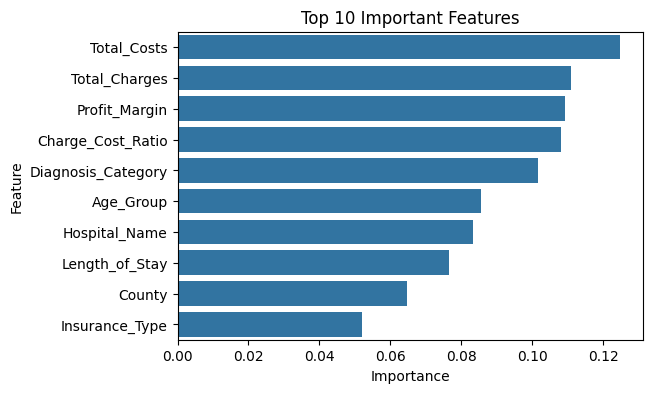

In [ ]:
# Visualization

plt.figure(figsize=(6,4))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

##### Performance Metrics
| Metric    | Value      |
| --------- | ---------- |
| Accuracy  | **62.16%** |
| Precision | **0.50**   |
| Recall    | **0.62**   |
| F1-Score  | **0.53**   |


The Random Forest Classification model achieved an accuracy of 62.16%, indicating moderate success in predicting patient discharge status. The results highlight the influence of class imbalance on model performance and demonstrate the applicability of machine learning techniques in healthcare analytics. Future improvements could further enhance predictive accuracy and support more reliable clinical decision-making.